# Deep Learning-Based Fire Detection System


This project aims to detect fire in images using a Convolutional Neural Network (CNN). The model is trained on fire and non-fire images and evaluated using various performance metrics.

# Importing Required Libraries

In this step, the necessary Python libraries for deep learning, image processing, and visualization are imported. TensorFlow and Keras are used to build the CNN model.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import matplotlib.pyplot as plt
import numpy as np
import os

2026-05-30 19:57:01.441526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780171021.637652      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780171021.690880      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780171022.147960      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780171022.148005      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780171022.148008      58 computation_placer.cc:177] computation placer alr

In [3]:
print(os.listdir('/kaggle/input/datasets/phylake1337/fire-dataset/fire_dataset'))

['non_fire_images', 'fire_images']


# Dataset Preparation

The fire dataset consists of two classes: fire and non-fire images. ImageDataGenerator is used for preprocessing and validation split.

In [4]:
dataset_path = '/kaggle/input/datasets/phylake1337/fire-dataset/fire_dataset'

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 800 images belonging to 2 classes.
Found 199 images belonging to 2 classes.


In [5]:
print(train_generator.class_indices)

{'fire_images': 0, 'non_fire_images': 1}


# Building the CNN Model

A Convolutional Neural Network (CNN) is designed to learn visual patterns from fire and non-fire images.

In [6]:
from tensorflow.keras import Input

model = Sequential()

model.add(Input(shape=(128,128,3)))

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

I0000 00:00:1780171065.397582      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Model Compilation

The model is compiled using the Adam optimizer and binary cross-entropy loss function.

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Architecture

The summary below shows the layers and trainable parameters of the CNN model.

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

The CNN model is trained for 10 epochs using the training dataset and evaluated on validation data.

In [13]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10


I0000 00:00:1780171311.680667     142 service.cc:152] XLA service 0x7ebe9c0059e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780171311.680705     142 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780171312.101869     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/25 ━━━━━━━━━━━━━━━━━━━━ 2:42 7s/step - accuracy: 0.2812 - loss: 0.7152

I0000 00:00:1780171315.231607     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 988ms/step - accuracy: 0.8475 - loss: 0.3274 - val_accuracy: 0.9045 - val_loss: 0.2218
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 676ms/step - accuracy: 0.9325 - loss: 0.1800 - val_accuracy: 0.9095 - val_loss: 0.1992
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 663ms/step - accuracy: 0.9500 - loss: 0.1242 - val_accuracy: 0.9497 - val_loss: 0.1499
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 679ms/step - accuracy: 0.9500 - loss: 0.1289 - val_accuracy: 0.9095 - val_loss: 0.1895
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 670ms/step - accuracy: 0.9663 - loss: 0.0874 - val_accuracy: 0.9598 - val_loss: 0.1432
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 664ms/step - accuracy: 0.9712 - loss: 0.0792 - val_accuracy: 0.9296 - val_loss: 0.1615
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 670ms/step - accuracy: 0.9700 - loss: 0.0720 - val_accuracy: 0.9397 - val_loss: 0.1574
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 713ms/step - accuracy: 0.9688 - loss: 0.0735 - val_accuracy: 0.959

# Accuracy Curve

This graph shows the training and validation accuracy during training.

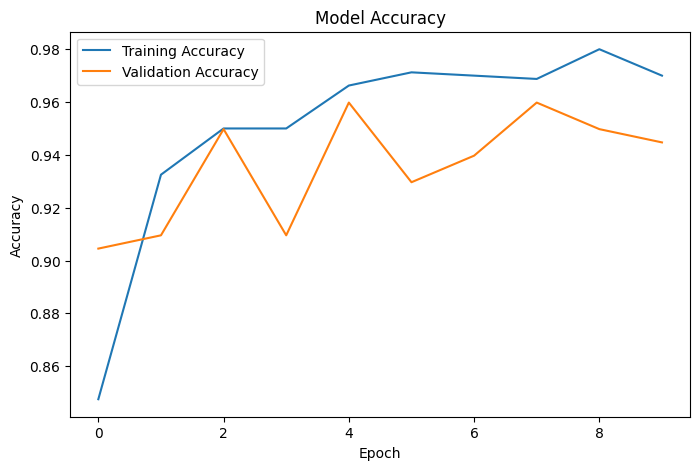

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Loss Curve

This graph illustrates the training and validation loss values throughout the training process.

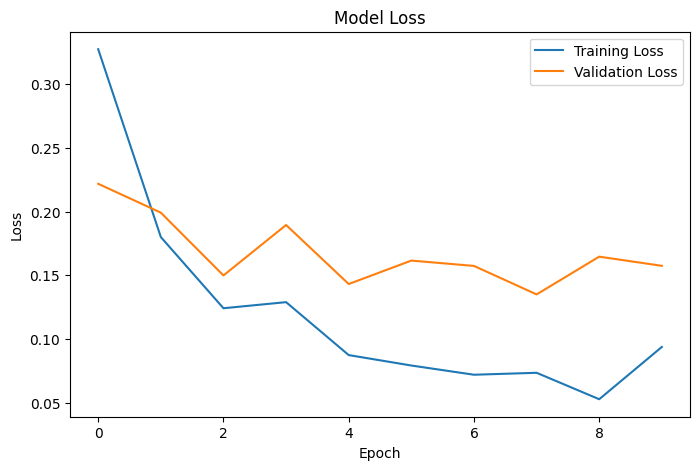

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Saving the Trained Model

The trained CNN model is saved for future use.

In [16]:
model.save('fire_detection_model.h5')

In [23]:
import os

print(os.listdir('/kaggle/input/datasets/naemaabdikani/yangn'))

['image_2026-05-30_232006744.png']


In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    '/kaggle/input/datasets/naemaabdikani/yangn/image_2026-05-30_232006744.png',
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction Value:", prediction[0][0])

if prediction[0][0] < 0.5:
    print(" Fire Detected")
else:
    print(" Non-Fire")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction Value: 1.897759e-07
 Fire Detected


# Model Evaluation

The trained model is evaluated using the validation dataset.

In [36]:
model.evaluate(validation_generator)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.9447 - loss: 0.1574


[0.15744218230247498, 0.9447236061096191]

# Confusion Matrix

The confusion matrix provides detailed information about the classification performance of the model.



<Figure size 600x600 with 0 Axes>

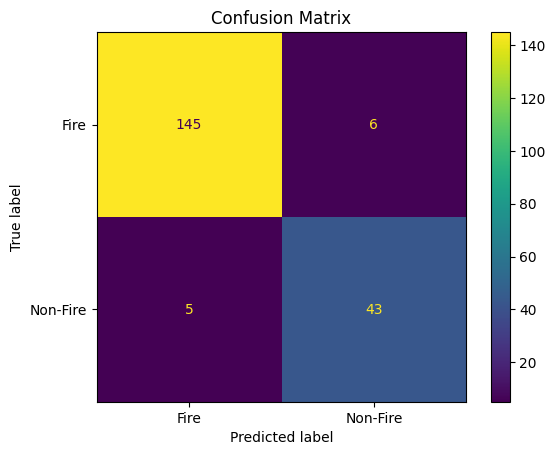

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

validation_generator.reset()

y_pred_prob = model.predict(validation_generator, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

y_true = validation_generator.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fire', 'Non-Fire']
)

plt.figure(figsize=(6,6))
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Fire Image Prediction

A new fire image is provided to the trained CNN model for prediction. The trained CNN model classifies the image as Fire or Non-Fire.

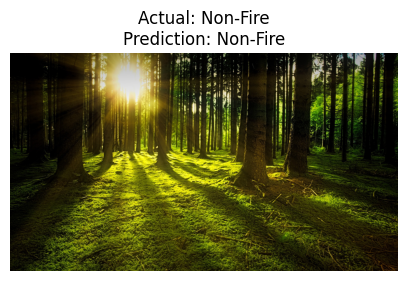

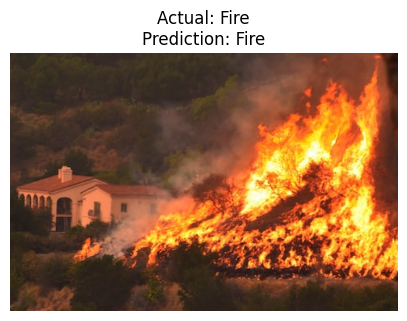

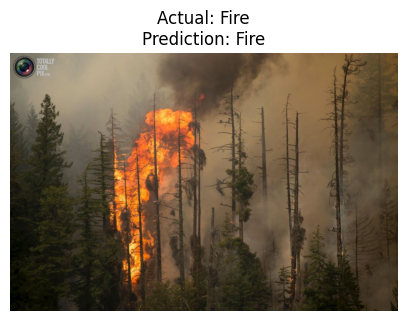

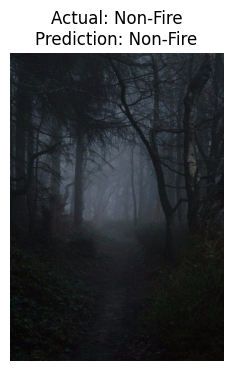

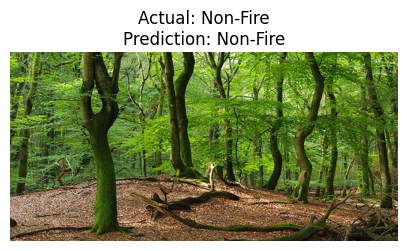

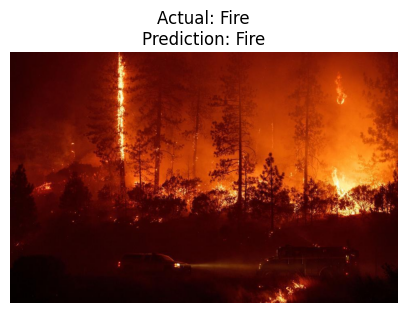

In [33]:
import random
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

fire_folder = "/kaggle/input/datasets/phylake1337/fire-dataset/fire_dataset/fire_images"
non_fire_folder = "/kaggle/input/datasets/phylake1337/fire-dataset/fire_dataset/non_fire_images"

samples = []

# 3 fire + 3 non-fire seç
for img_name in random.sample(os.listdir(fire_folder), 3):
    samples.append((os.path.join(fire_folder, img_name), "Fire"))

for img_name in random.sample(os.listdir(non_fire_folder), 3):
    samples.append((os.path.join(non_fire_folder, img_name), "Non-Fire"))

random.shuffle(samples)

for img_path, actual_label in samples:

    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_label = "Fire" if prediction[0][0] < 0.5 else "Non-Fire"

    plt.figure(figsize=(5,4))
    plt.imshow(image.load_img(img_path))
    plt.title(
        f"Actual: {actual_label}\nPrediction: {predicted_label}"
    )
    plt.axis("off")
    plt.show()

# Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to classify fire and non-fire images. The model was trained on a fire image dataset and achieved a validation accuracy of 94.47%. Performance evaluation using accuracy curves, loss curves, and a confusion matrix demonstrated that the model can effectively distinguish fire images from non-fire images. Furthermore, testing on a new fire image confirmed that the trained model can successfully detect fire in unseen data. These results show that deep learning techniques can be effectively applied to automated fire detection systems.
